# NB03C — Validación de speckle óptico 2D hasta $z=5\lambda$

**Proyecto:** simulación de speckle óptico mediante PINN-SIREN y la ecuación
de Helmholtz.

Este notebook extiende NB03 y NB03B desde $1\lambda$ y $2\lambda$ hasta
$5\lambda$. La extensión directa con una única PINN global no convergió. La
solución aceptada conserva la ecuación completa de Helmholtz, las coordenadas
cartesianas $(x,z)$ y la condición de Cauchy dura, pero divide el intervalo en
cinco subdominios consecutivos de una longitud de onda.

La referencia del **espectro angular no se usa como etiqueta de entrenamiento
ni para seleccionar los pesos**. Solo se consulta después para cuantificar el
error del campo complejo.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (HERE, *HERE.parents):
    marker = candidate / 'results' / 'nb03_distance_pilot' / 'nb03c_z5_validation' / 'validation_summary.json'
    if marker.exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del proyecto ni el resumen NB03C.')

SUMMARY_PATH = PROJECT_ROOT / 'results' / 'nb03_distance_pilot' / 'nb03c_z5_validation' / 'validation_summary.json'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
print('Estructura del proyecto localizada correctamente.')
print(f"Resumen: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

Estructura del proyecto localizada correctamente.
Resumen: results\nb03_distance_pilot\nb03c_z5_validation\validation_summary.json


## 1. Problema físico normalizado

El campo complejo transversal $E(\tilde x,\tilde z)$ satisface

$$
\frac{\partial^2 E}{\partial \tilde x^2}+
\frac{\partial^2 E}{\partial \tilde z^2}+
\tilde k^2E=0,
\qquad \tilde k=2\pi,
$$

donde $\tilde x=x/\lambda$ y $\tilde z=z/\lambda$. Por tanto, el dominio de
esta prueba es

$$
\tilde x\in[-10,10),\qquad \tilde z\in[0,5].
$$

El hecho de llegar a $\tilde z=5$ significa propagar cinco longitudes de onda;
no significa cambiar de coordenadas ni abandonar la formulación 2D $(x,z)$.

## 2. Control negativo: una sola PINN global

Antes de usar subdominios se intentó entrenar la arquitectura oficial
$\omega_0=1$ directamente sobre $0\leq\tilde z\leq5$. Ese control es
importante porque evita atribuir el éxito a una selección favorable de datos.

In [2]:
direct = summary['direct_single_domain_control']
print('CONTROL DIRECTO EN UNA SOLA REGIÓN')
print('-' * 54)
print(f"L2 complejo final       : {100*direct['l2_full_final']:.4f}%")
print(f"Máximo propagante       : {100*direct['l2_propagating_max']:.4f}%")
print(f"Coherencia final        : {direct['coherence_full_final']:.6f}")
print(f"Aceptado                : {direct['accepted']}")

CONTROL DIRECTO EN UNA SOLA REGIÓN
------------------------------------------------------
L2 complejo final       : 118.4662%
Máximo propagante       : 150.1972%
Coherencia final        : 0.050195
Aceptado                : False


El fallo directo no invalida Helmholtz ni NB01–NB03B. Muestra un problema de
optimización: al aumentar el dominio, una sola red debe representar demasiada
acumulación de fase y el residuo admite mínimos que no corresponden al campo
saliente buscado.

## 3. Continuación por cinco subdominios

El campo se descompone en 41 modos propagantes:

$$
E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x},
\qquad
a_m''+\tilde k_{z,m}^2a_m=0.
$$

Para el bloque $j$, se usa la coordenada local
$\xi=\tilde z-j\in[0,1]$ y se impone

$$
a_m^{(j)}(\xi)=A_m^{(j)}+\xi B_m^{(j)}+
\xi^2N_{\theta_j,m}(\xi).
$$

Las condiciones de interfaz se transfieren exactamente:

$$
A_m^{(j)}=a_m^{(j-1)}(1),\qquad
B_m^{(j)}={a_m^{(j-1)}}'(1).
$$

Así, el campo y su derivada longitudinal son continuos por construcción. La
SIREN conserva cuatro capas ocultas de 128 neuronas y añade una escala
sinusoidal global entrenable en cada bloque. Esto sigue siendo una
**PINN-SIREN**, pero ya no es una única red global: son cinco PINN locales
acopladas físicamente.

## 4. Criterios de aceptación

Cada pantalla debe cumplir simultáneamente:

- $L^2$ complejo final menor que 5 %;
- máximo $L^2$ propagante menor que 5 % en los 201 planos;
- coherencia mayor que 0.99;
- correlación de intensidad mayor que 0.99;
- diferencia absoluta de contraste menor que 0.05;
- discontinuidad de campo y derivada menor que $10^{-6}$.

In [3]:
rows = summary['per_screen']
header = ('pantalla', 'L2 final (%)', 'máx. L2 (%)', 'z del máximo', 'coherencia', 'corr. I', '|ΔC|', 'aceptada')
print(f"{header[0]:>8} {header[1]:>13} {header[2]:>13} {header[3]:>12} {header[4]:>12} {header[5]:>10} {header[6]:>10} {header[7]:>10}")
for row in rows:
    print(
        f"{row['screen_seed']:>8d} "
        f"{100*row['l2_full_final']:>13.4f} "
        f"{100*row['l2_propagating_max']:>13.4f} "
        f"{row['l2_propagating_max_z']:>12.2f} "
        f"{row['coherence_full_final']:>12.6f} "
        f"{row['intensity_correlation_full_final']:>10.6f} "
        f"{row['contrast_difference']:>10.6f} "
        f"{str(row['accepted']):>10}"
    )

pantalla  L2 final (%)   máx. L2 (%) z del máximo   coherencia    corr. I       |ΔC|   aceptada
      42        3.0827        3.5067         4.85     0.999601   0.999313   0.007153       True
     123        2.2600        2.2600         5.00     0.999779   0.999721   0.000081       True
     321        1.8559        1.9073         4.95     0.999854   0.999794   0.005951       True
     777        2.4425        2.7806         4.30     0.999712   0.999634   0.004211       True
    2026        1.5807        1.5807         5.00     0.999917   0.999852   0.004433       True


In [4]:
aggregate = summary['aggregate']
print('RESULTADO AGREGADO — NB03C EN z=5 lambda')
print('-' * 62)
print(f"L2 completo final medio : {100*aggregate['l2_full_final']['mean']:.4f}%")
print(f"Peor L2 completo final  : {100*aggregate['l2_full_final']['maximum']:.4f}%")
print(f"Peor máximo sobre z     : {100*aggregate['l2_propagating_max']['maximum']:.4f}%")
print(f"Coherencia media        : {aggregate['coherence_full_final']['mean']:.6f}")
print(f"Correlación I media     : {aggregate['intensity_correlation_full_final']['mean']:.6f}")
print(f"Pantallas aceptadas     : {aggregate['accepted_screens']}/{aggregate['total_screens']}")

RESULTADO AGREGADO — NB03C EN z=5 lambda
--------------------------------------------------------------
L2 completo final medio : 2.2444%
Peor L2 completo final  : 3.0827%
Peor máximo sobre z     : 3.5067%
Coherencia media        : 0.999772
Correlación I media     : 0.999663
Pantallas aceptadas     : 5/5


## 5. Error a lo largo de toda la propagación

La figura siguiente evita evaluar únicamente el plano final. Las líneas
verticales marcan las interfaces entre PINN locales.

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\rober\AppData\Local\Temp\ipykernel_20120\2805331879.py:9: SyntaxWarning: invalid escape sequence '\l'
  title='NB03C: error en 201 planos hasta $5\lambda$')


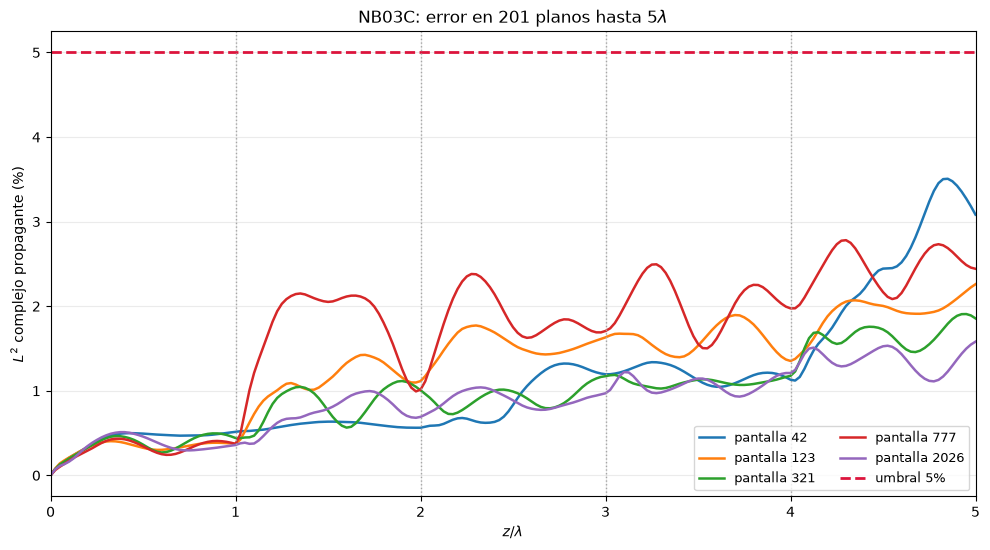

Figura guardada: results\figures\nb03c_z5_l2_multiscreen.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.6))
for row in rows:
    data = np.load(PROJECT_ROOT / row['arrays_path'])
    ax.plot(data['z_lambda'], 100*data['l2_propagating'], lw=1.8, label=f"pantalla {row['screen_seed']}")
ax.axhline(5, color='crimson', ls='--', lw=2, label='umbral 5%')
for boundary in (1, 2, 3, 4):
    ax.axvline(boundary, color='0.65', ls=':', lw=1)
ax.set(xlabel=r'$z/\lambda$', ylabel=r'$L^2$ complejo propagante (%)',
       title='NB03C: error en 201 planos hasta $5\lambda$')
ax.set_xlim(0, 5)
ax.grid(alpha=.25)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
path_l2 = FIGURES_DIR / 'nb03c_z5_l2_multiscreen.png'
fig.savefig(path_l2, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_l2.relative_to(PROJECT_ROOT)}")

## 6. Evolución espacial representativa

Se muestra la intensidad de la pantalla 42 calculada por espectro angular y
por la PINN por bloques. La tercera gráfica es el error de campo normalizado
por la amplitud RMS de cada plano.

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
C:\Users\rober\AppData\Local\Temp\ipykernel_20120\2942286369.py:27: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('Propagación de speckle hasta $5\lambda$ — pantalla 42', y=1.02)


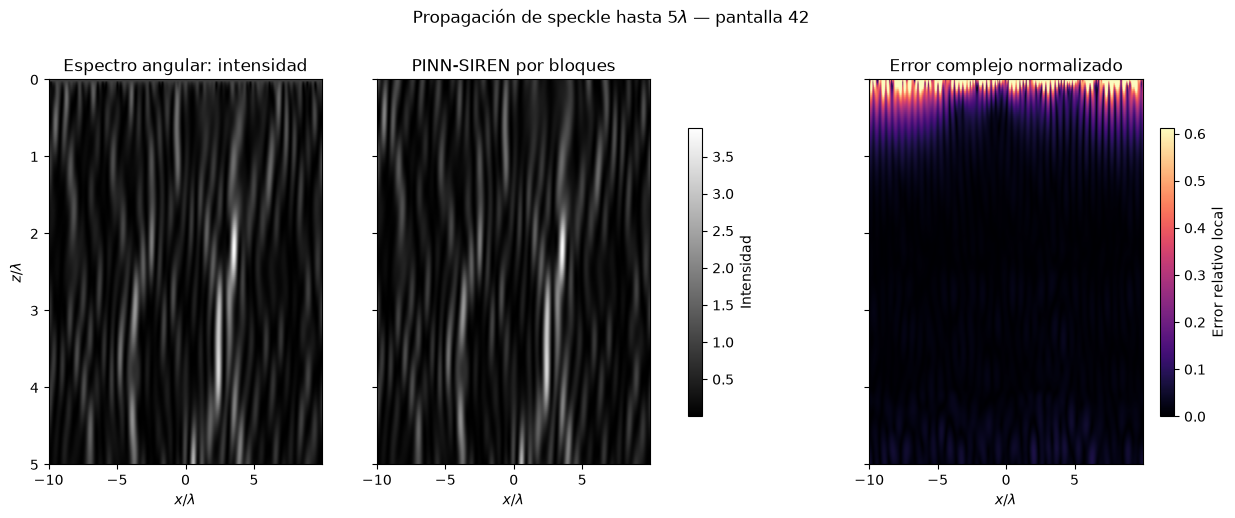

Figura guardada: results\figures\nb03c_z5_propagation_screen42.png


In [6]:
row42 = next(row for row in rows if row['screen_seed'] == 42)
data42 = np.load(PROJECT_ROOT / row42['arrays_path'])
reference42 = np.load(PROJECT_ROOT / 'results' / 'nb03_angular_spectrum_reference_z1_corr0.10.npz')
x = reference42['x_lambda']
z = data42['z_lambda']
field_ref = data42['field_full']
field_pred = data42['field_pred']
intensity_ref = np.abs(field_ref)**2
intensity_pred = np.abs(field_pred)**2
rms = np.sqrt(np.mean(np.abs(field_ref)**2, axis=1, keepdims=True))
error = np.abs(field_pred-field_ref) / np.maximum(rms, 1e-12)
extent = [x.min(), x.max(), z.max(), z.min()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
im0 = axes[0].imshow(intensity_ref, aspect='auto', extent=extent, cmap='gray')
axes[0].set_title('Espectro angular: intensidad')
im1 = axes[1].imshow(intensity_pred, aspect='auto', extent=extent, cmap='gray')
axes[1].set_title('PINN-SIREN por bloques')
im2 = axes[2].imshow(error, aspect='auto', extent=extent, cmap='magma', vmin=0,
                     vmax=np.percentile(error, 99))
axes[2].set_title('Error complejo normalizado')
for ax in axes:
    ax.set_xlabel(r'$x/\lambda$')
axes[0].set_ylabel(r'$z/\lambda$')
fig.colorbar(im0, ax=axes[:2], shrink=.75, label='Intensidad')
fig.colorbar(im2, ax=axes[2], shrink=.75, label='Error relativo local')
fig.suptitle('Propagación de speckle hasta $5\lambda$ — pantalla 42', y=1.02)
path_map = FIGURES_DIR / 'nb03c_z5_propagation_screen42.png'
fig.savefig(path_map, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_map.relative_to(PROJECT_ROOT)}")

El campo completo contiene inicialmente componentes evanescentes que no están
en la base de 41 modos propagantes. Por ello, cerca de $z=0$ puede aparecer una
franja de diferencia frente al campo completo sin violar la condición de
Cauchy de la proyección propagante.

## 7. Plano final en $z=5\lambda$

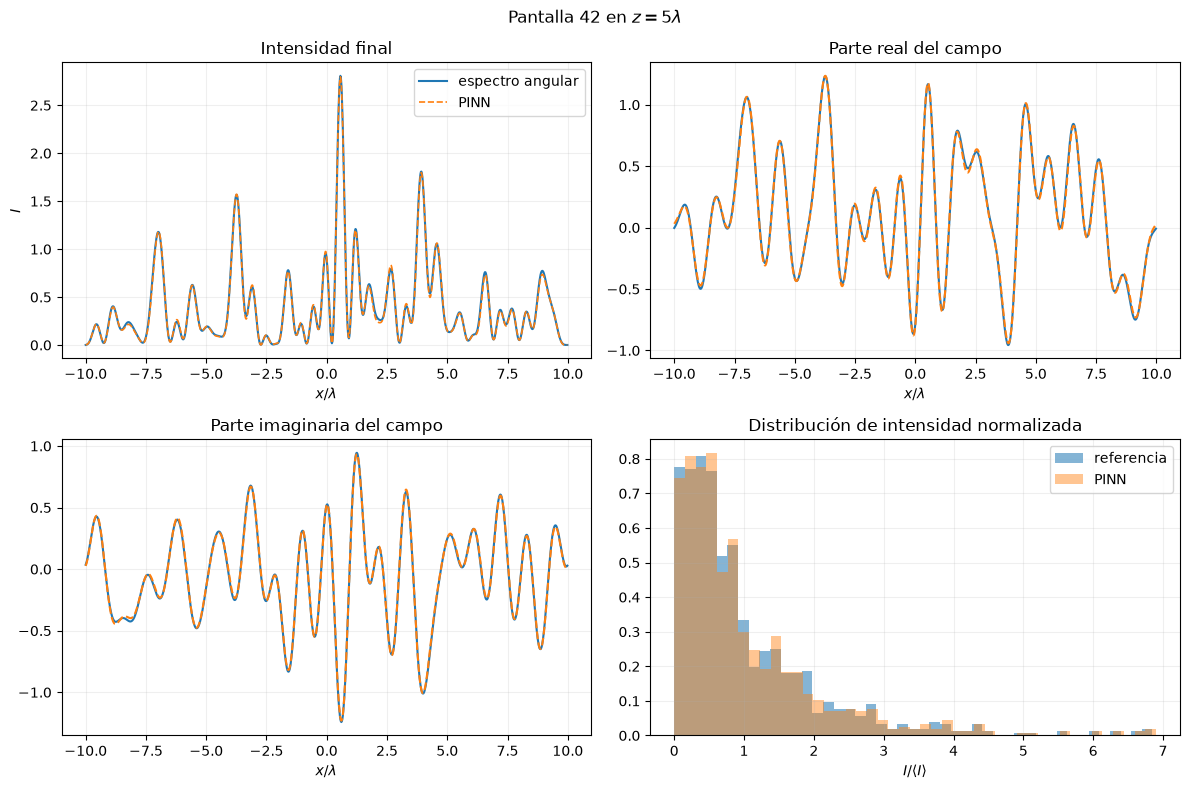

Figura guardada: results\figures\nb03c_z5_final_plane_screen42.png


In [7]:
iref = intensity_ref[-1]
ipred = intensity_pred[-1]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(x, iref, label='espectro angular', lw=1.5)
axes[0,0].plot(x, ipred, '--', label='PINN', lw=1.2)
axes[0,0].set(title='Intensidad final', xlabel=r'$x/\lambda$', ylabel='$I$')
axes[0,0].legend()
axes[0,1].plot(x, field_ref[-1].real, label='referencia')
axes[0,1].plot(x, field_pred[-1].real, '--', label='PINN')
axes[0,1].set(title='Parte real del campo', xlabel=r'$x/\lambda$')
axes[1,0].plot(x, field_ref[-1].imag, label='referencia')
axes[1,0].plot(x, field_pred[-1].imag, '--', label='PINN')
axes[1,0].set(title='Parte imaginaria del campo', xlabel=r'$x/\lambda$')
axes[1,1].hist(iref/iref.mean(), bins=45, density=True, alpha=.55, label='referencia')
axes[1,1].hist(ipred/ipred.mean(), bins=45, density=True, alpha=.45, label='PINN')
axes[1,1].set(title='Distribución de intensidad normalizada', xlabel=r'$I/\langle I\rangle$')
axes[1,1].legend()
for ax in axes.flat:
    ax.grid(alpha=.2)
fig.suptitle(r'Pantalla 42 en $z=5\lambda$')
fig.tight_layout()
path_final = FIGURES_DIR / 'nb03c_z5_final_plane_screen42.png'
fig.savefig(path_final, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_final.relative_to(PROJECT_ROOT)}")

## 8. Continuidad e integridad científica

Los errores de interfaz se calculan después del entrenamiento. Un valor nulo
o cercano a precisión de máquina confirma que la solución del bloque siguiente
empieza exactamente con el campo y la derivada del bloque anterior.

In [8]:
print(f"{'pantalla':>8} {'salto campo':>15} {'salto derivada':>17} {'residuo máx. bloque':>21}")
for row in rows:
    print(f"{row['screen_seed']:>8d} {row['interface_field_max_abs']:>15.3e} "
          f"{row['interface_derivative_max_abs']:>17.3e} {row['max_slab_residual_rmse']:>21.3e}")

assert summary['all_screens_accepted']
assert len(rows) == 5
assert all(row['l2_full_final'] < .05 for row in rows)
assert all(row['l2_propagating_max'] < .05 for row in rows)
assert all(row['coherence_full_final'] > .99 for row in rows)
assert all(row['intensity_correlation_full_final'] > .99 for row in rows)
assert all(row['contrast_difference'] < .05 for row in rows)
assert all(row['interface_field_max_abs'] < 1e-6 for row in rows)
assert all(row['interface_derivative_max_abs'] < 1e-6 for row in rows)
print('\nComprobaciones de integridad: APROBADAS.')

pantalla     salto campo    salto derivada   residuo máx. bloque
      42       0.000e+00         0.000e+00             1.555e-02
     123       0.000e+00         0.000e+00             1.033e-02
     321       0.000e+00         0.000e+00             1.368e-02
     777       0.000e+00         0.000e+00             1.790e-02
    2026       0.000e+00         0.000e+00             1.103e-02

Comprobaciones de integridad: APROBADAS.


## 9. Reentrenamiento opcional y seguro

El notebook carga resultados validados para que su ejecución sea rápida. El
entrenamiento costoso permanece en scripts separados y no se inicia
accidentalmente al elegir **Run All**.

In [9]:
RUN_TRAINING = False
if RUN_TRAINING:
    raise RuntimeError(
        'El reentrenamiento debe ejecutarse explícitamente desde '
        'scripts/experiments/nb03_adaptive_slabs.py y '
        'nb03_adaptive_slabs_refine.py para conservar los registros.'
    )
else:
    print('Entrenamiento desactivado: se usan los artefactos validados.')

Entrenamiento desactivado: se usan los artefactos validados.


## 10. Conclusión y alcance

La continuación por subdominios validó cinco campos conocidos de speckle en
todo el intervalo $0\leq z\leq5\lambda$. El error complejo final medio fue
aproximadamente 2.24 % y el peor máximo observado en 201 planos fue 3.51 %.

La conclusión correcta es:

> Una cadena de cinco PINN-SIREN modales, acopladas mediante condiciones de
> Cauchy duras, reproduce la propagación de las cinco realizaciones evaluadas
> hasta $5\lambda$ con error inferior al 5 %.

Esto **no demuestra** que una sola PINN global funcione a cualquier distancia,
ni que el modelo generalice a una pantalla nueva sin entrenamiento. Tampoco es
todavía una validación experimental de laboratorio.